# DATASET HOUSING, valori dei prezzi delle case

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('housing.csv')

ModuleNotFoundError: No module named 'seaborn'

## Stampiamo le prime righe per controllare che il dataset sia stato importato correttamente

In [5]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## INFO
- numero di record
- n di valori non-null di ogni colonna, e di conseguenza quello di valori nulli
- tipo di dato

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


## Describe
### da controllare:
- min e max, controlliamo se hanno senso
- media e 50%, controlliamo quanto sono vicini come valori
- media e deviazione standard, controlliamo quanto la deviazione strd e' grande rispetto alla media

In [7]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### Annotazioni min max:
- housing median age MIN = 1, la media di eta delle case di un quartiere = 1 non convince
- total_rooms MIN = 1
- total_rooms MAX = 39320 non ha senso
  

### La differenza in una riga

La **Media** fa la somma di tutti e divide, quindi viene influenzata dai valori estremi. La **Mediana** è il valore che sta esattamente nel mezzo della fila, quindi ignora gli estremi.

---

### L'Esempio Chiarificatore

Immagina un bar in cui ci sono **5 persone** con questi risparmi nel portafoglio:

> 10€, 15€, 20€, 25€, 30€

* **Mediana:** **20€** (è il valore esattamente al centro della fila).
* **Media:** **20€** (la somma è 100€, diviso 5 fa 20€).

In questo momento, media e mediana coincidono: il gruppo è omogeneo.

#### Cosa succede se entra Bill Gates?

All'improvviso nel bar entra una sesta persona che ha in tasca **60.000€**. Ora i dati sono:

> 10€, 15€, 20€, 25€, 30€, 60.000€

* **Mediana:** **22,50€** (la media tra i due valori centrali, 20 e 25). Resta una fotografia realistica di una persona comune nel bar.
* **Media:** **10.016€** (la somma ora è 60.100€, diviso 6).

### Perché è importante valutarle insieme?

Se guardassi solo la **media (10.016€)**, penseresti che quel bar è frequentato da soli ricchi.
Mettendola a confronto con la **mediana (22,50€)**, noti subito un distacco enorme (**Media $>$ Mediana**). Questo ti dice istantaneamente una cosa: nel tuo dataset c'è un valore anomalo gigantesco che sta falsando la media.

## Analisi media e mediana:
- total rooms ha valori estremi come possiamo vedere anche dal max che spostano la media a destra della mediana
- in generale molte colonne hanno il valore max elevato che porta quasi ovunque a una differenza tra media e mediana

Se la **media** ti dice qual è il "centro" dei tuoi dati, la **deviazione standard** ti dice **quanto i dati sono vicini o lontani da quel centro**. In pratica, misura quanto sono "sparpagliati" i tuoi numeri.

### L'esempio pratico: il tiro a segno

Immagina due tiratori che sparano 5 colpi ciascuno su un bersaglio. Entrambi mirano al centro (la media).

* **Tiratore Costante (Deviazione Standard Bassa):** Tutti i suoi colpi sono ravvicinati, quasi l'uno sull'altro, a pochissimi millimetri dal centro. I suoi dati sono compatti.
* **Tiratore Instabile (Deviazione Standard Alta):** Un colpo va cortissimo, uno va lunghissimo, uno a destra, uno a sinistra. Matematicamente, il "centro geometrico" dei suoi colpi è ancora il centro del bersaglio, ma i proiettili sono sparsi ovunque.

---

### Un esempio con i numeri

Prendiamo due studenti, entrambi con una **media del 7**:

* **Studente A ha questi voti:** `7, 7, 7`
* I suoi voti non oscillano mai. La distanza da 7 è zero.
* La sua deviazione standard è **pari a 0** (nessuna variabilità).


* **Studente B ha questi voti:** `4, 7, 10`
* La media è sempre 7 ($\frac{4+7+10}{3} = 7$), ma i voti sono agli estremi: un'insufficienza grave e un punteggio massimo.
* La sua deviazione standard è **molto alta** (forte variabilità).



### Perché è fondamentale?

Conoscere solo la media non basta. Dire che un fiume ha una profondità *media* di un metro e mezzo potrebbe farti annegare se la **deviazione standard è alta**, perché significa che ci saranno punti profondi tre metri e punti profondi dieci centimetri.

La deviazione standard ti dice se puoi fidarti della media oppure no.

## Analisi deviazione standard sul dataset:
- quasi tutte le colonne hanno una deviazone standard molto vicina al valore della media, tutti le distribuzioni lavorano quindi su un discreto range

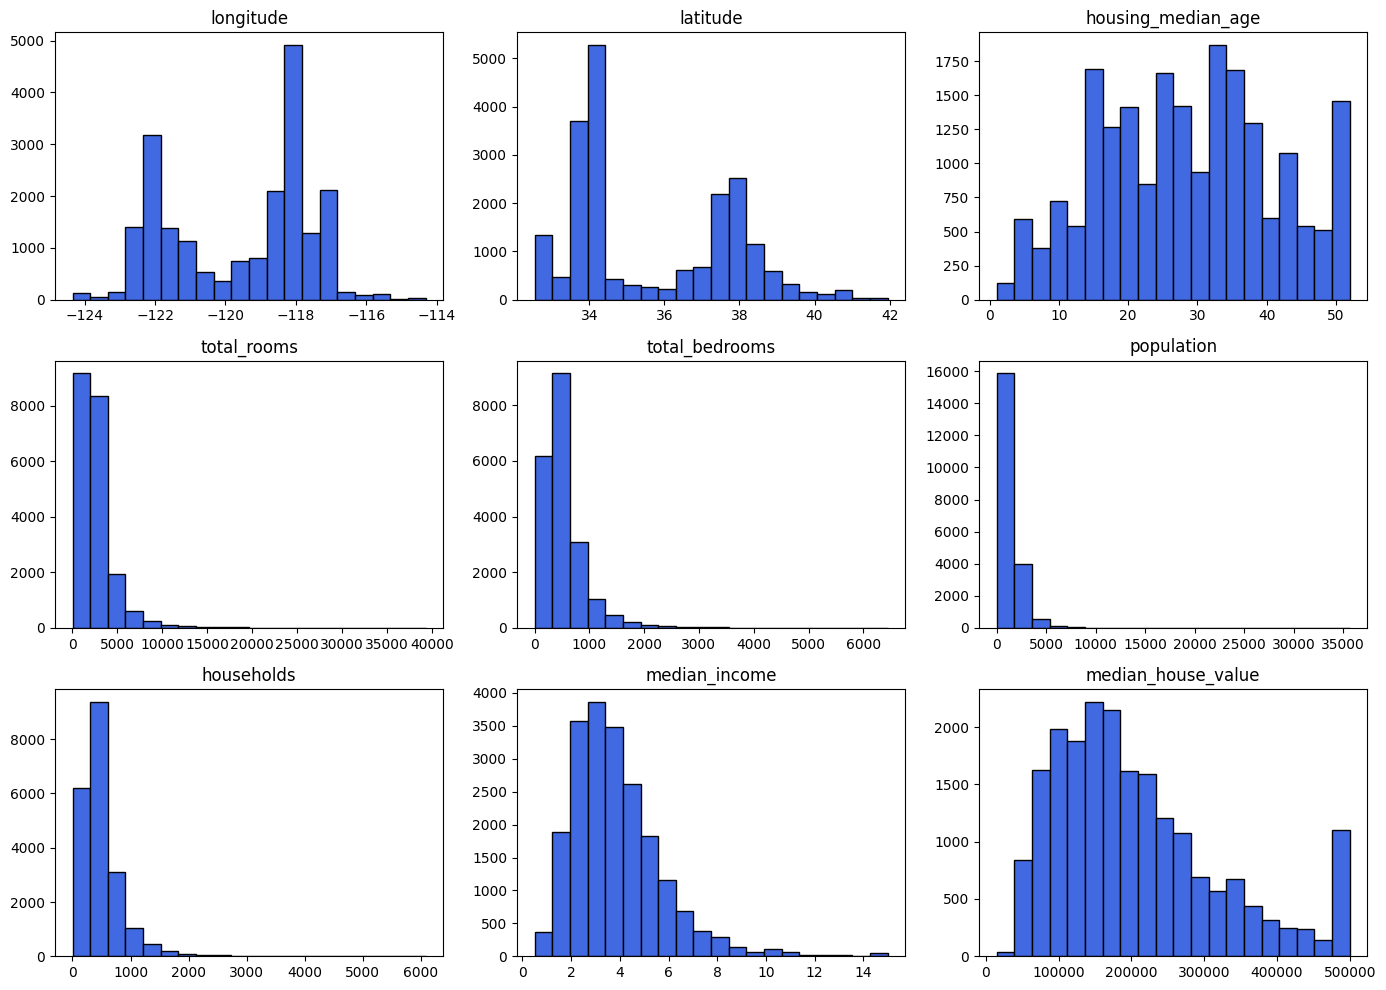

In [8]:
# Selezioniamo solo le colonne numeriche e creiamo la griglia
df.hist(bins=20, figsize=(14, 10), color='royalblue', edgecolor='black', grid=False)

# Regoliamo lo spazio tra i grafici per non far sovrapporre i testi
plt.tight_layout()
plt.show()

## L'obbiettivo e' valutare i grafici gaussiani e non, trovare quelli skewed (non simmetrici) e eventuali eccezioni e casi particolari come il valore di 500000 su median house value

## Outliers : valori estremi che influenzano da soli le nostre metriche statistiche

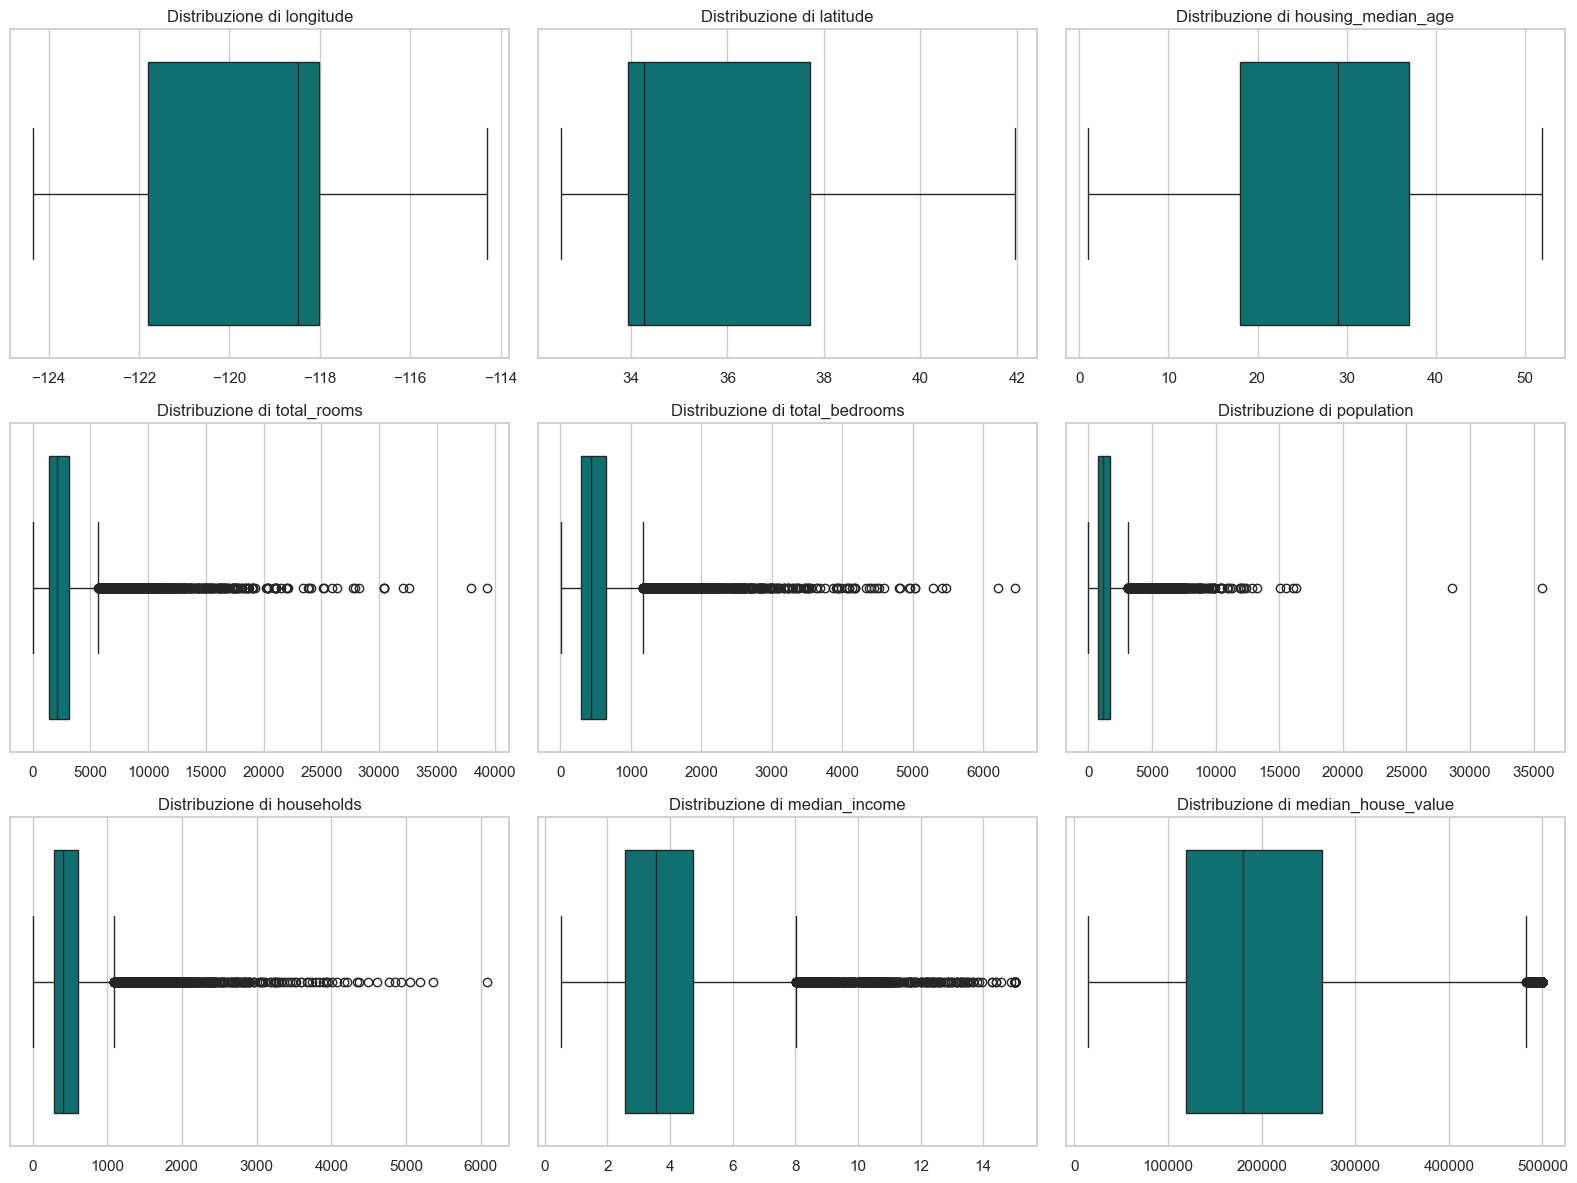

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

# 1. Selezioniamo solo le colonne numeriche
numeric_cols = df.select_dtypes(include=['number']).columns
num_vars = len(numeric_cols)

# 2. Calcoliamo quante righe servono per la griglia (ipotizzando 3 colonne per riga)
cols_per_row = 3
rows_needed = math.ceil(num_vars / cols_per_row)

# 3. Creiamo la figura della dimensione corretta
fig, axes = plt.subplots(rows_needed, cols_per_row, figsize=(16, rows_needed * 4))

# Appiattiamo la matrice degli assi per ciclarla facilmente, in caso di griglie multi-riga
axes = axes.flatten()

# 4. Generiamo un boxplot per ogni colonna
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x=col, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribuzione di {col}', fontsize=12)
    axes[i].set_xlabel('')  # Rimuoviamo l'etichetta dell'asse X per non duplicare il titolo

# 5. Nascondiamo i grafici vuoti avanzati (es. se abbiamo 8 variabili in una griglia da 9)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Ottimizziamo gli spazi e mostriamo la griglia
plt.tight_layout()
plt.show()

La **correlazione** è l'indice statistico che ti dice se due cose diverse si muovono insieme e in che modo lo fanno. In pratica, risponde alla domanda: *"Se la variabile A aumenta, cosa fa la variabile B? Aumenta, diminuisce o va per i fatti suoi?"*

---

### Le tre direzioni della correlazione

La correlazione si misura con un numero che va da **-1 a +1** e può prendere tre strade:

1. **Correlazione Positiva ($> 0$):** Le due cose si muovono nella **stessa direzione**. Se una sale, sale anche l'altra.
2. **Correlazione Negativa ($< 0$):** Le due cose si muovono in **direzioni opposte**. Se una sale, l'altra scende.
3. **Correlazione Nulla ($0$):** Non c'è alcun legame. Il movimento di una cosa non ti dice nulla su cosa farà l'altra.

---

### L'esempio pratico: una giornata al mare

Immagina di osservare cosa succede in una località balneare al variare della **temperatura esterna**:

* **Esempio Positivo (Vendita di Gelati):** Più la temperatura sale, più aumentano i gelati venduti. I due dati crescono insieme.
* **Esempio Negativo (Vendita di Cioccolata Calda):** Più la temperatura sale, più la vendita di cioccolata calda crolla. Se un dato sale, l'altro scende.
* **Esempio Nullo (Iscrizioni a un corso di Cinese):** Che ci siano 15°C o 40°C, il numero di persone che decide di studiare cinese in quella città rimane totalmente casuale e indipendente dal meteo.

---

### La trappola d'oro: "Correlazione non significa Causalità"

Questo è l'errore più comune in assoluto quando si analizzano i dati. Il fatto che due numeri si muovano insieme **non significa che uno sia la causa dell'altro**.

> **Il paradosso degli squali**
> I dati dimostrano che nei mesi in cui aumentano le vendite di gelati, aumentano matematicamente anche gli attacchi di squali nel mondo. C'è una fortissima *correlazione positiva*.
> Significa che mangiare gelati attira gli squali? Ovviamente no. Significa che vendere meno gelati salverà delle vite? Nemmeno.
> C'è una terza variabile nascosta (la causa reale): **l'estate**. Con il caldo, le persone mangiano più gelati *e* fanno più bagni in mare, aumentando la probabilità statistica di incontrare uno squalo.

### In sintesi

La correlazione è un fantastico strumento per **trovare indizi** e legami nascosti nel tuo dataset, ma spetta sempre a te analizzare il contesto per capire se quel legame ha un senso logico o se è solo una coincidenza guidata da un terzo fattore.

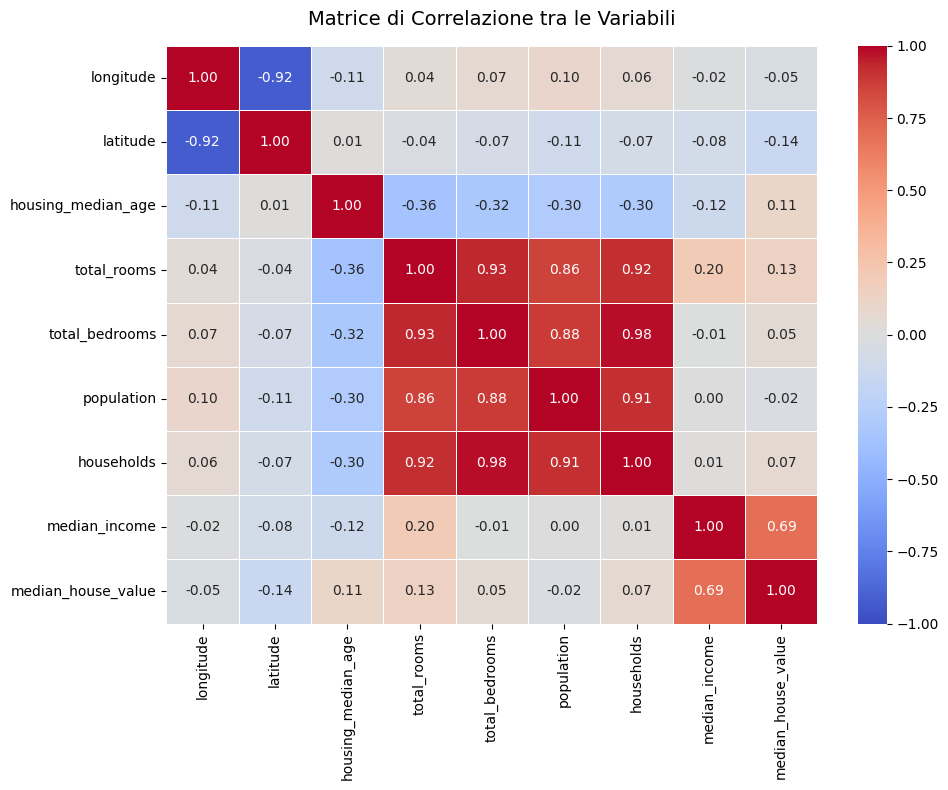

In [10]:
import seaborn as sns

# 1. Calcoliamo la matrice di correlazione (solo sulle colonne numeriche)
corr_matrix = df.corr(numeric_only=True)

# 2. Creiamo la Heatmap con Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

# 3. Titolo e mostra grafico
plt.title('Matrice di Correlazione tra le Variabili', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## DISCRETIZZAZIONE delle distribuzioni
dividere la variabile target median_house_value in 3 sezioni, economica, media, costosa e vedere come si comportano gli altri parametri in base a questa nuova divisione

Numero di case per categoria:
price_category
Economica    6884
Costosa      6880
Media        6876
Name: count, dtype: int64
--------------------------------------------------


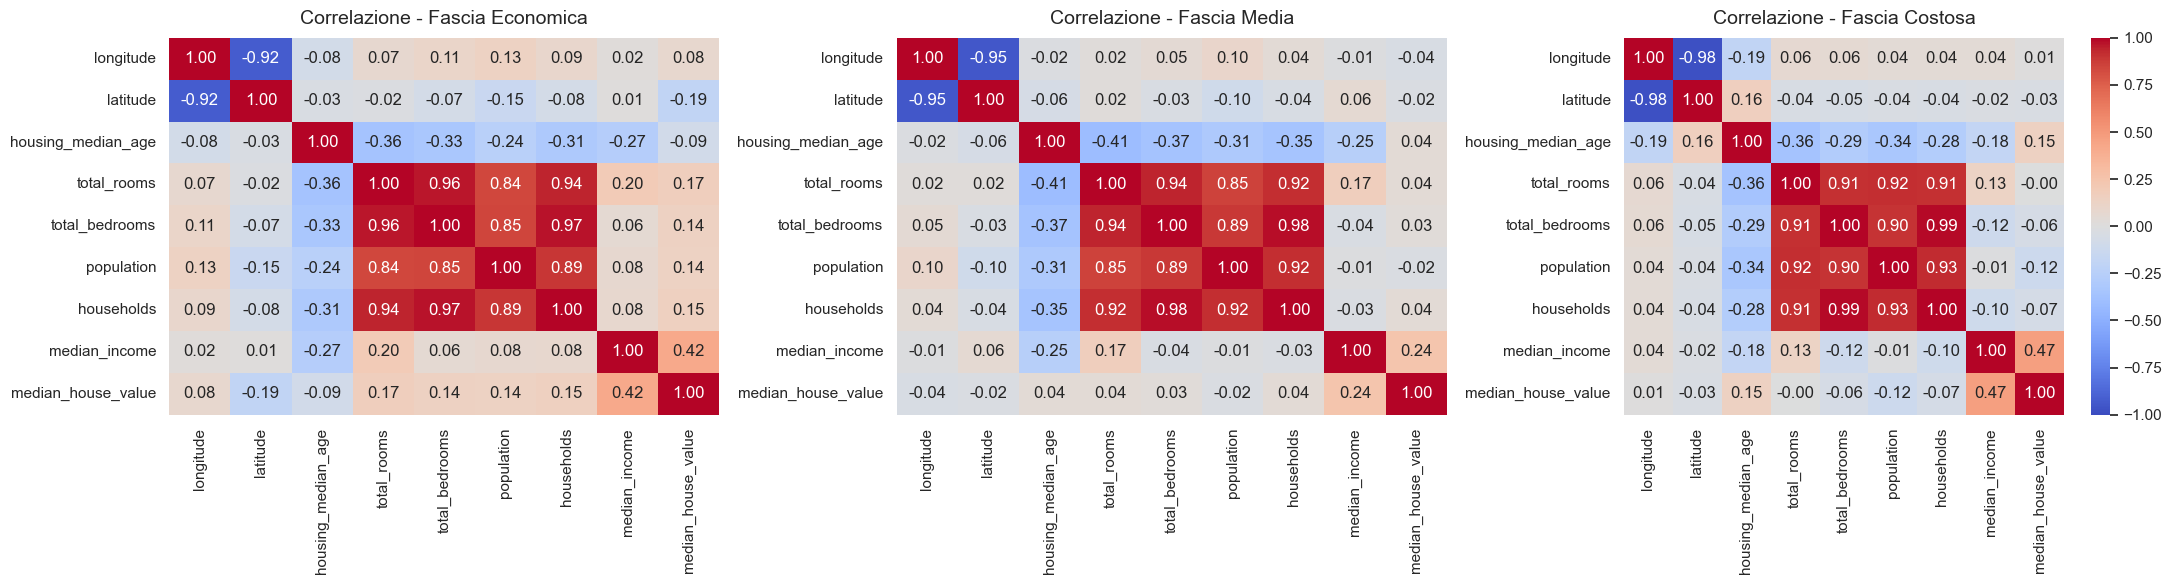

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Discretizzazione in 3 fasce (Economica, Media, Costosa) usando i quantili
df['price_category'] = pd.qcut(df['median_house_value'], 
                               q=3, 
                               labels=['Economica', 'Media', 'Costosa'])

# Verifichiamo la distribuzione delle case nelle tre categorie
print("Numero di case per categoria:")
print(df['price_category'].value_counts())
print("-" * 50)

# 2. Creiamo una figura con 3 sotto-grafici (uno per ogni categoria)
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
categories = ['Economica', 'Media', 'Costosa']

# 3. Generiamo una matrice di correlazione per ciascuna fascia
for i, cat in enumerate(categories):
    # Filtriamo il dataframe per la categoria corrente
    df_filtered = df[df['price_category'] == cat]
    
    # Calcoliamo la matrice di correlazione (solo colonne numeriche)
    # Escludiamo anche median_house_value perché all'interno della stessa fascia varia poco
    corr_sub = df_filtered.select_dtypes(include=['number']).corr()
    
    # Disegniamo la heatmap sull'asse corrispondente
    sns.heatmap(corr_sub, annot=True, cmap='coolwarm', fmt=".2f", 
                vmin=-1, vmax=1, ax=axes[i], cbar=(i == 2))
    
    axes[i].set_title(f'Correlazione - Fascia {cat}', fontsize=14, pad=10)

plt.tight_layout()
plt.show()

1 Crearsi un'aspettativa in base alle conoscenze, case sulla cosa costano di piu

2 Controllo la mia aspettativa con i dati, facendo operazioni e grafici

3 se la mia aspettativa e' soddisdfatta perfetto, se non ho sbagliato l'aspettativa devo capire perche' il risultato e' diverso da quello che mi aspettavo

L'obbiettivo e' sempre quello di trovare pattern e antipattern all'interno dei dati